# Point patterns — is it clustered, or is that just where the people are?

**Companion to deck `05-spatial-dependence` (Part 2 — Measurements, Point patterns).**

### What makes this notebook different from the other two

| Notebook | The locations are… | We model… | Example |
|---|---|---|---|
| `02_spatial_autocorrelation` | given (census tracts) | a **value** on them | median house value |
| `02b_variograms` | given (soil samples) | a **value** on them | zinc concentration |
| **this one** | **the data themselves** | **why they are where they are** | a drug incident happened *here* |

That is the whole shift. There is no column to predict. Nobody chose to sample at these
spots — the events *chose themselves*, and the pattern they leave is the evidence. Our
questions are:

1. Are the events **clustered**, **regular**, or **random** — and *compared to what?*
2. At what **scale** does the pattern appear?
3. Is it **interaction** between events, or just a **busy part of town**?

Question 3 is the hard one. It is where most published point pattern analysis goes wrong,
and this notebook builds carefully toward it.

### What this notebook does, step by step

1. Build the three canonical patterns — **clustered**, **random**, **regular** — synthetically, and learn to read **NNI** on data whose truth you control (§1).
2. Load the real **San Francisco crime** data (drugs, robbery, car theft, vandalism; July–December 2012) and define the study **window** (§2).
3. Chop the city into **quadrats**, count events, and test against the **Poisson/CSR** null with the **variance-to-mean ratio** and $\chi^2$ — then watch the verdict move when you change the grid (**MAUP**) (§3).
4. Smooth the points into an intensity surface with **KDE**, and see that the **bandwidth**, not the kernel, makes the map (§4).
5. Run **second-order** analysis — and discover that raw **NNI = 0.061** for drugs is an artifact of **tied coordinates**: 3,896 incidents sit at only 1,076 distinct sites (§5).
6. Use the whole distance distribution — **$G$, $F$, $K$/$L$** — against **Monte-Carlo envelopes**, and compare **effect sizes** rather than $p$-values (§6).
7. Spring the trap: simulate a pattern with **zero interaction** that is merely proportional to **population**, and show it still "rejects CSR" — then fix it with an **inhomogeneous null** (§7).

### How to work through this

Read it top to bottom and run every cell — later sections reuse earlier variables. The
structure is deliberate:

- **§1** teaches the tools on **synthetic data whose truth we control**. You cannot judge
  a statistic on real data if you have never watched it behave on data where you already
  know the answer.
- **§2–§5** apply those tools to **real San Francisco crime data**, one method at a time.
- **§6** springs the trap that everything has been building toward.

Every number printed here is computed here; the deck quotes these outputs.

## 0) Setup

Two notes on the imports, because both matter later:

- **`pointpats`** provides `g_test`, `f_test`, `k_test` — the distance functions of §5,
  each bundled with Monte-Carlo simulation envelopes. Install with
  `pip install pointpats` (it is in `requirements-extras.txt`).
- **`shapely.prepared.prep`** builds a *prepared geometry*. We ask "is this point inside
  San Francisco?" tens of thousands of times; a prepared geometry caches an index and
  makes each test roughly an order of magnitude faster. Without it the simulations in §6
  crawl.

In [1]:
import warnings
warnings.filterwarnings("ignore")          # geopandas/shapely emit noisy deprecations

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from scipy import stats                    # chi-square distribution for the quadrat test
from scipy.spatial import cKDTree          # fast nearest-neighbour queries (NNI, §4)
from shapely.geometry import Point, box    # test points; quadrat cells
from shapely.prepared import prep          # fast repeated point-in-polygon tests

from pointpats import g_test, f_test, k_test   # distance functions + CSR envelopes (§5)

%config InlineBackend.figure_format = "retina"

# Every simulation below draws from this generator. One fixed seed = reproducible numbers:
# re-run the notebook and you get the same figures. Change it and the *conclusions* should
# not move — if they do, the finding was noise. That is a test you should actually run.
SEED = 42
rng = np.random.default_rng(SEED)

# The crime data is projected in EPSG:2227 (California State Plane III), whose unit is the
# US survey FOOT. Distances are therefore computed in feet and converted for reporting:
# a "500" in this CRS means 500 feet, not metres. Mixing the two silently is a classic
# way to produce confident nonsense, so we convert at the point of printing, every time.
FT_PER_M = 3.28084

---

## 1) First, learn to read the pattern — on data whose truth we know

Before touching real data, build the three canonical patterns yourself. Each has the
**same number of events** in the **same square window**. Only the *process* differs:

- **Clustered** — events attract, or a shared driver concentrates them (disease cases,
  shops, drug dealing). We simulate it as a *Thomas process*: scatter a few unseen
  "parents", then scatter offspring around each one.
- **Random (CSR)** — events ignore each other entirely. **This is our null hypothesis**,
  and it is worth staring at: real CSR looks lumpier than most people expect. The eye
  wants to see clusters in it. That is exactly why we need statistics.
- **Regular** — events repel: competition for space (trees, territories, franchise
  outlets). Simulated as a jittered lattice.

In [2]:
n = 200                                   # same n for all three, so counts can't explain anything

# --- Random (CSR): every location equally likely, no interaction whatsoever.
pattern_random = rng.uniform(0, 1, (n, 2))

# --- Clustered (Thomas process): 12 unseen "parents", offspring scattered tightly around each.
#     sd=0.035 sets the cluster radius; smaller sd = tighter clumps.
parents = rng.uniform(0.1, 0.9, (12, 2))
offspring_per_parent = n // 12
pattern_clustered = np.clip(
    np.repeat(parents, offspring_per_parent, axis=0)
    + rng.normal(0, 0.035, (offspring_per_parent * 12, 2)),
    0, 1)                                 # clip keeps offspring inside the unit square

# --- Regular: a lattice, jittered slightly so it isn't perfectly artificial.
side = int(np.ceil(np.sqrt(n)))
gx, gy = np.meshgrid(np.linspace(.03, .97, side), np.linspace(.03, .97, side))
pattern_regular = np.column_stack([gx.ravel(), gy.ravel()])[:n] + rng.normal(0, 0.012, (n, 2))

print(f"three patterns, n = {n} each, all in the unit square [0,1] x [0,1]")

three patterns, n = 200 each, all in the unit square [0,1] x [0,1]


### The nearest-neighbour index (NNI), from first principles

Take each event, measure the distance to its **closest** neighbour, average those
distances. Call it $\bar d_{\text{obs}}$.

Is that average small? Small *compared to what?* We need the value randomness would have
produced. For a homogeneous Poisson process of intensity $\lambda$ (events per unit area),
the expected nearest-neighbour distance has a closed form:

$$\bar d_{\text{exp}} = \frac{1}{2\sqrt{\lambda}}, \qquad \lambda = \frac{n}{|A|}$$

The ratio of the two is the **nearest-neighbour index**:

$$\text{NNI} = \frac{\bar d_{\text{obs}}}{\bar d_{\text{exp}}}
\qquad\begin{cases}
< 1 & \text{neighbours closer than chance} \Rightarrow \textbf{clustered}\\
\approx 1 & \textbf{random}\\
> 1 & \text{neighbours farther than chance} \Rightarrow \textbf{regular}
\end{cases}$$

Read that formula once more and notice what it depends on: $|A|$, **the window you drew**.
We will make it lie later using nothing but that.

In [3]:
# NNI. `area` is an explicit argument, not a global, because the whole point of §4 is that
# the window is an assumption you make — so the code should force you to state it.
def nni(pts, area):
    # cKDTree.query(pts, k=2) returns, for each point, the 2 closest points in the set:
    # column 0 is the point ITSELF (distance 0), column 1 is its true nearest neighbour.
    d, _ = cKDTree(pts).query(pts, k=2)
    d_obs = d[:, 1].mean()                       # observed mean nearest-neighbour distance
    lam = len(pts) / area                        # intensity: events per unit area
    d_exp = 1 / (2 * np.sqrt(lam))               # expected mean NN distance under CSR
    return d_obs, d_exp, d_obs / d_exp

for label, pts in [("clustered", pattern_clustered),
                   ("random (CSR)", pattern_random),
                   ("regular", pattern_regular)]:
    d_obs, d_exp, index = nni(pts, area=1.0)     # unit square -> area = 1
    verdict = "clustered" if index < 0.9 else ("regular" if index > 1.1 else "random")
    print(f"{label:14s} mean NN dist = {d_obs:.4f}   expected = {d_exp:.4f}   "
          f"NNI = {index:.2f}  -> {verdict}")

clustered      mean NN dist = 0.0169   expected = 0.0361   NNI = 0.47  -> clustered
random (CSR)   mean NN dist = 0.0358   expected = 0.0354   NNI = 1.01  -> random
regular        mean NN dist = 0.0523   expected = 0.0354   NNI = 1.48  -> regular


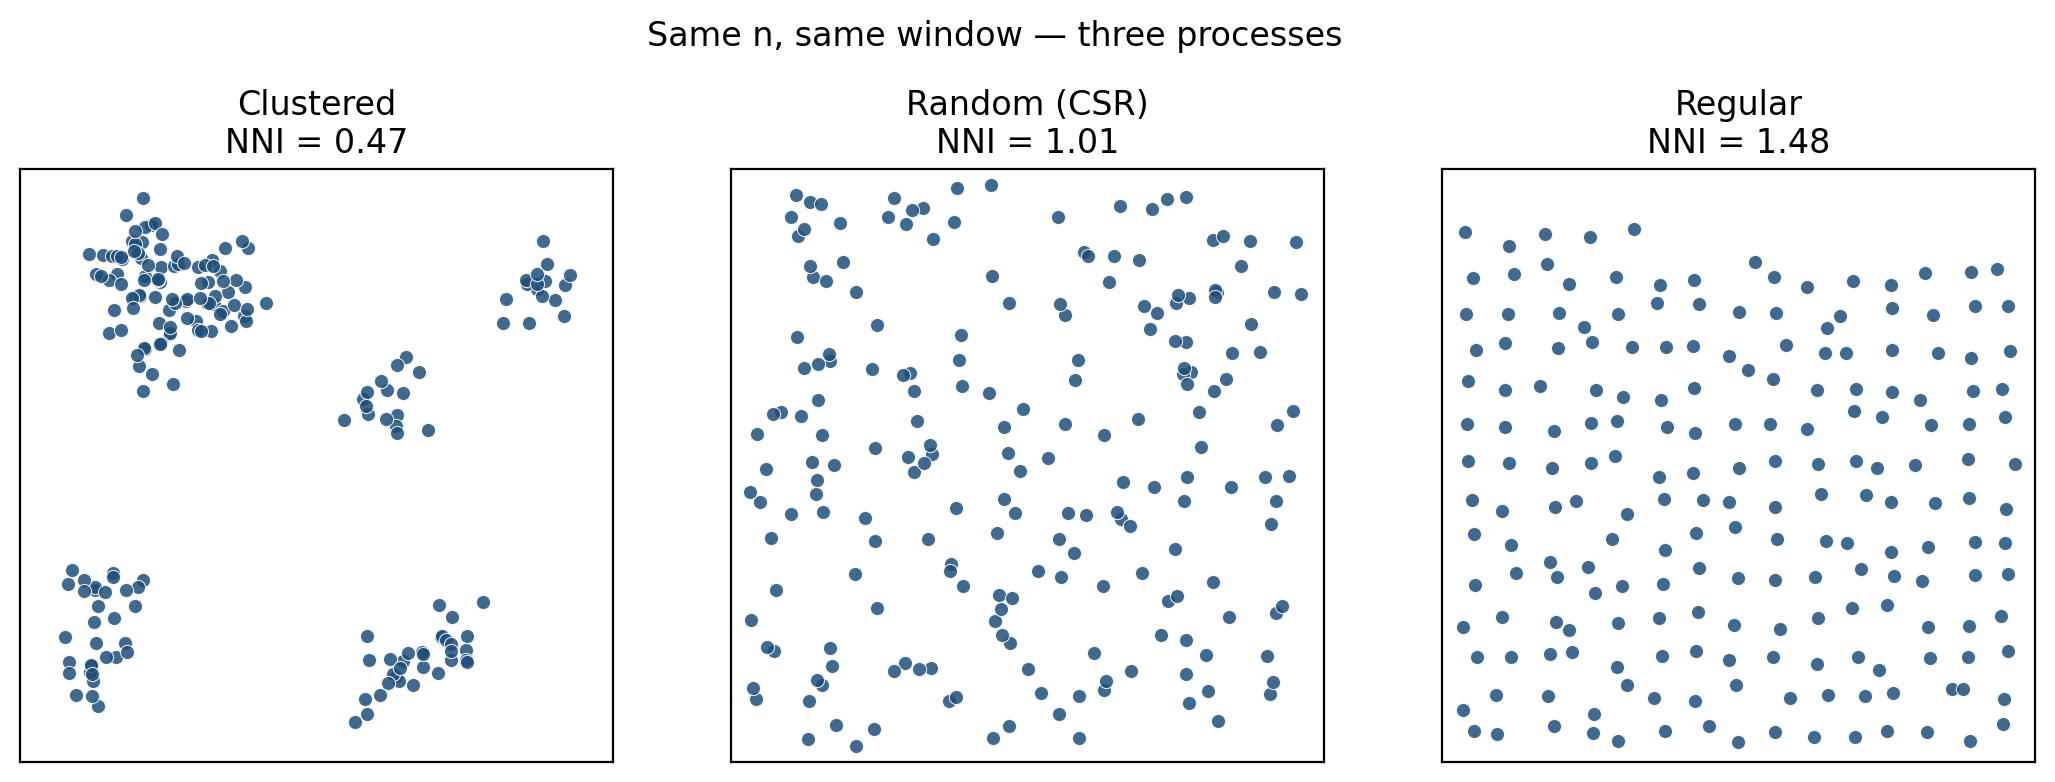

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, pts, title in [(axes[0], pattern_clustered, "Clustered"),
                       (axes[1], pattern_random, "Random (CSR)"),
                       (axes[2], pattern_regular, "Regular")]:
    ax.scatter(pts[:, 0], pts[:, 1], s=26, c="#1f4e79", alpha=.85, edgecolor="w", lw=.4)
    ax.set_title(f"{title}\nNNI = {nni(pts, 1.0)[2]:.2f}")
    ax.set_xlim(-.02, 1.02); ax.set_ylim(-.02, 1.02)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
plt.suptitle("Same n, same window — three processes")
plt.show()

### Read the output

The statistic works, and now you have seen it work:

- **Clustered ≈ 0.47** — neighbours are less than half as far as chance predicts.
- **Random ≈ 1.01** — hovering at 1, which is the definition of "nothing to report".
- **Regular ≈ 1.48** — neighbours held *farther* apart than chance.

Two things worth internalising from the middle panel. First, **CSR is not "evenly
spread"**: it has clumps and voids, because independent events land where they like. The
regular panel, not the random one, is what most people draw when asked for "random". If
you judge clustering by eye, you will find it everywhere. Second, **the random panel's NNI
is not exactly 1.00** — a random draw scatters around its expectation. So "is 1.01
different from 1?" is a real question, and answering it needs a null *distribution*, not a
formula. §3 builds one.

> **Lesson —** a point pattern is never "clustered" in the absolute; it is clustered
> *relative to a null model*, so the null is the part you must state out loud.

### Your turn

Before moving on, try these — each takes one edit and pays for itself:

1. In the clustered generator, change `sd=0.035` to `0.1`. How much clustering does NNI
   still detect? Where does it stop being able to tell clustering from CSR?
2. Change `SEED` and re-run §1. How far does the random pattern's NNI wander from 1.00?
   That spread *is* your uncertainty — remember its size when you meet 0.586 in §4.
3. Compute NNI on the **random** pattern twice more, passing `area=4.0` and then
   `area=0.25` — i.e. lying about the window size in each direction. You should get
   NNI ≈ 0.51 ("clustered!") and ≈ 2.03 ("regular!") from *the same 200 points*, without
   moving one of them. Claiming a **bigger** window lowers $\lambda$, which inflates
   $\bar d_{\text{exp}}$, which manufactures clustering. This is §5's punchline arriving
   early — and in §7 you will do it to real data with the Pacific Ocean.

---

## 2) The real data: San Francisco crime, July–December 2012

Now the tools meet reality. The data is `libpysal`'s **SanFran Crime** (Jul–Dec 2012),
prepared into `data/sfcrime/sfcrime.gpkg` with five layers: four crime types as points, the
census block groups (carrying **population**, which we need in §6), and the study boundary.

**A point pattern is events *plus* a window.** The window is not decoration: $\lambda =
n/|A|$ appears in every statistic we just wrote, so the boundary you draw silently sets
your answers. We use San Francisco's **land boundary** — dissolved from the block groups —
rather than a bounding box, which would be roughly half ocean and would deflate $\lambda$
for everything.

In [5]:
GPKG = "data/sfcrime/sfcrime.gpkg"

drugs = gpd.read_file(GPKG, layer="drugs")        # DRUG/NARCOTIC incidents
cartheft = gpd.read_file(GPKG, layer="cartheft")  # VEHICLE THEFT
blocks = gpd.read_file(GPKG, layer="blocks")      # census block groups + Population
window = gpd.read_file(GPKG, layer="boundary").geometry.iloc[0]   # SF land polygon

# Everything below needs coordinates as a plain (n, 2) array, not shapely objects.
def xy(g):
    return np.column_stack([g.geometry.x, g.geometry.y])

# Window area: square feet -> km2. (FT_PER_M**2 sq ft per m2, then 1e6 m2 per km2.)
area_ft2 = window.area
area_km2 = area_ft2 / (FT_PER_M ** 2 * 1e6)

for name, g in [("drugs", drugs), ("car theft", cartheft)]:
    print(f"{name:10s} n = {len(g):5,}   lambda = {len(g)/area_km2:5.2f} events / km2")
print(f"\nwindow: {area_km2:.1f} km2, CRS EPSG:{drugs.crs.to_epsg()}, "
      f"{len(blocks)} block groups, {int(blocks.Population.sum()):,} residents")

drugs[["Category", "Descript", "Date", "PdDistrict"]].head(3)

drugs      n = 3,896   lambda = 31.57 events / km2
car theft  n = 3,377   lambda = 27.36 events / km2

window: 123.4 km2, CRS EPSG:2227, 579 block groups, 805,235 residents


,Category,Descript,Date,PdDistrict
0,DRUG/NARCOTIC,POSSESSION OF MARIJUANA,2012-07-01,BAYVIEW
1,DRUG/NARCOTIC,POSSESSION OF MARIJUANA,2012-07-01,BAYVIEW
2,DRUG/NARCOTIC,POSSESSION OF MARIJUANA,2012-07-01,BAYVIEW


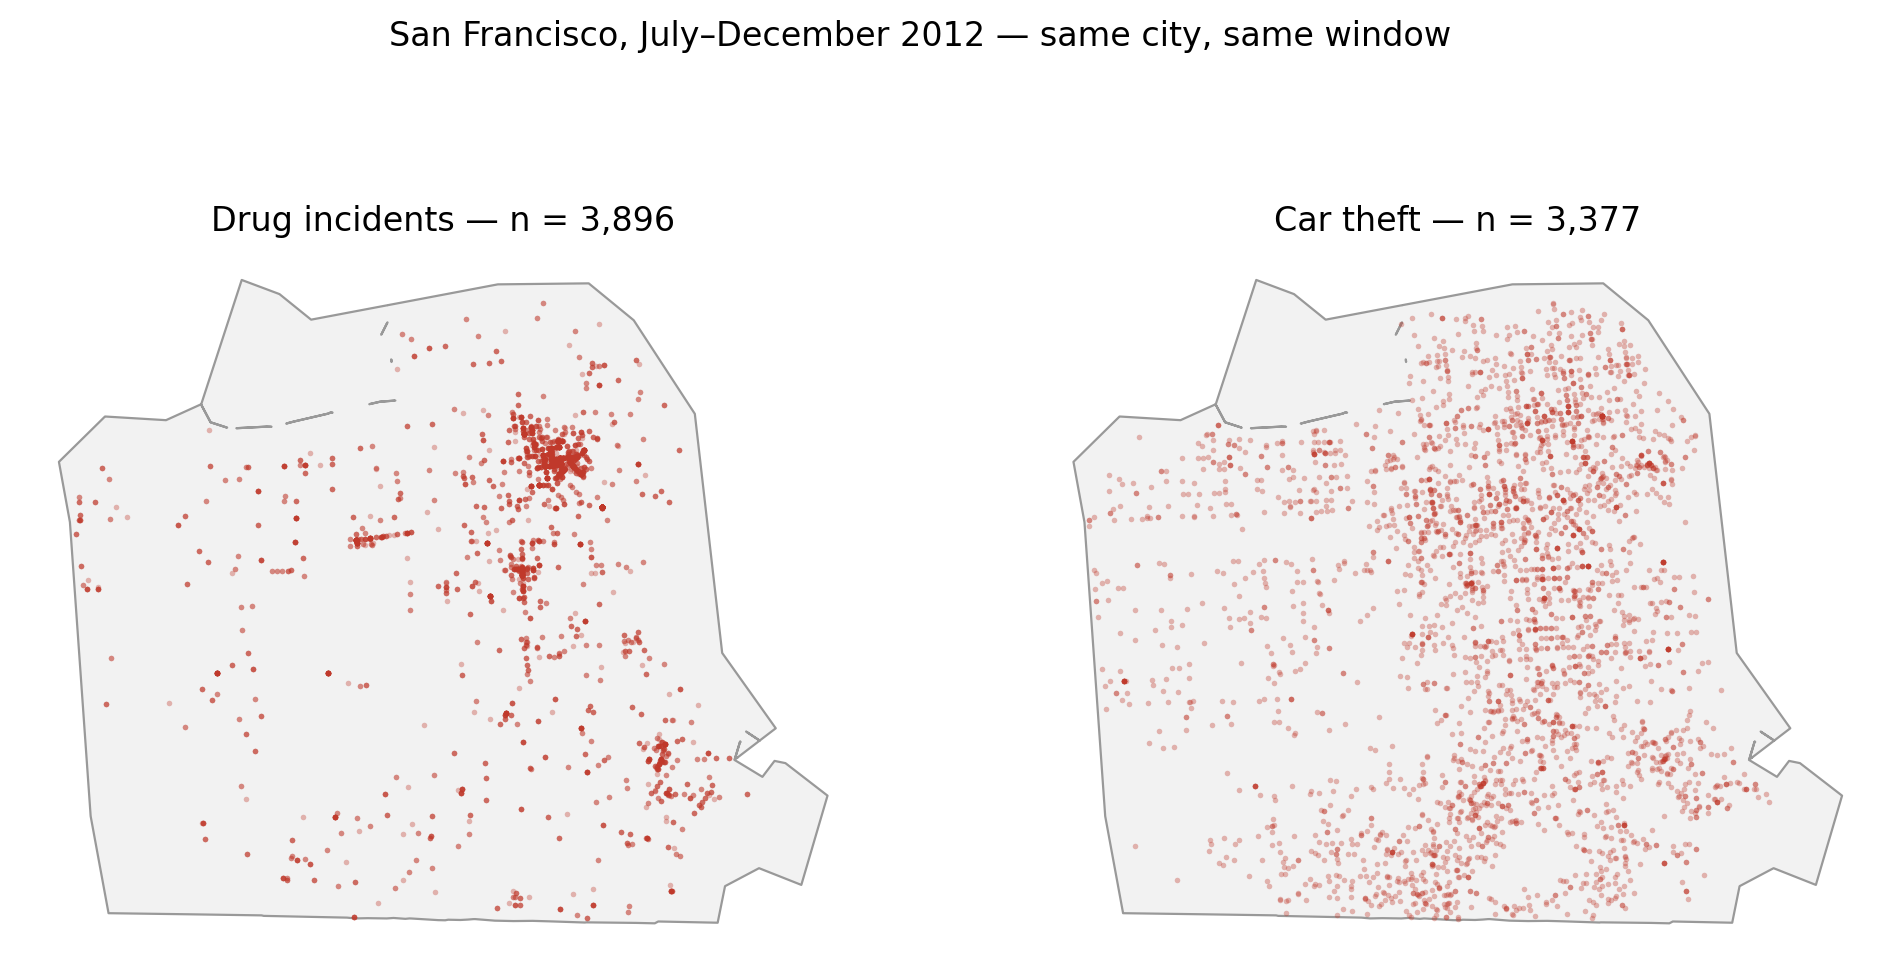

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, g, title in [(axes[0], drugs, "Drug incidents"), (axes[1], cartheft, "Car theft")]:
    gpd.GeoSeries([window]).plot(ax=ax, color="#f2f2f2", edgecolor="#999", lw=.8)
    # alpha is doing real work: thousands of overlapping dots would otherwise read as
    # one solid mass and hide exactly the concentration we are trying to see.
    ax.scatter(g.geometry.x, g.geometry.y, s=4, c="#c0392b", alpha=.35, lw=0)
    ax.set_title(f"{title} — n = {len(g):,}")
    ax.set_axis_off(); ax.set_aspect("equal")
plt.suptitle("San Francisco, July–December 2012 — same city, same window")
plt.show()

### Read the output

Two crime types with **almost the same intensity** — 31.6 vs 27.4 events per km² — and
obviously different patterns. Drugs collapse onto a few blocks (that dense knot is the
Tenderloin); car theft is smeared across the whole city.

This pairing is the spine of the notebook. Keep asking, as each new statistic arrives:
*does it separate these two, and does it say anything about **why** they differ?* A
statistic that merely reports "both are clustered, $p < 0.001$" has told you nothing you
could not see here.

### The null we will measure everything against: CSR

**Complete Spatial Randomness** = the homogeneous Poisson process. It asserts **two**
things at once, and keeping them apart is the single most important idea in this notebook:

1. **Uniform intensity** — $\lambda$ is the same everywhere in the window. No place is
   special.
2. **Independence** — events do not influence one another. Where one lands tells you
   nothing about where the next will.

Under CSR the count in any region $A$ is Poisson distributed: $N(A) \sim
\text{Poisson}(\lambda|A|)$. That single fact powers the entire next section.

A pattern can break CSR by failing **either** assumption — and they tell completely
different stories:

| What broke | The story | Example |
|---|---|---|
| **Independence** | events genuinely *interact* | contagion; a dealer attracts dealing |
| **Uniform intensity** | the *place* varies | more crime where more people are |

**A test that rejects CSR cannot tell you which one broke.** Hold onto that. It is §6.

---

## 3) Quadrats: chop, count, compare to Poisson

The oldest idea in the field, and still the most intuitive: **lay a grid over the window
and count events per cell.**

Why does counting tell us anything? Because of the Poisson fact above. The Poisson
distribution has one defining property:

$$\text{variance} = \text{mean}$$

So if events fell independently at constant intensity, the cell counts should have a
variance about equal to their mean. Any departure is evidence. That gives a test statistic
for free — the **variance-to-mean ratio**:

$$\text{VMR} = \frac{s^2}{\bar n} \qquad
\begin{cases}
\approx 1 & \text{random (Poisson)}\\
> 1 & \textbf{clustered} — \text{some cells packed, many empty} \Rightarrow \text{variance inflated}\\
< 1 & \textbf{regular} — \text{counts nearly equal} \Rightarrow \text{variance suppressed}
\end{cases}$$

**One trap to handle before we start.** A cell that is 90% ocean will record "few crimes",
and that is not evidence of anything about crime — it is evidence about water. Cells must
have equal *area at risk*, so we keep only cells that are **≥99% land**. Watch for this
below; it is the kind of detail that decides whether a result is real.

In [7]:
# Lay an m x m grid over the window's bounding box and count events per cell.
# Returns: counts (m x m), a mask of which cells are usable, and the grid edges.
def quadrat_counts(pts, m=10, min_land=0.99):
    minx, miny, maxx, maxy = window.bounds
    xe = np.linspace(minx, maxx, m + 1)          # cell edges, x
    ye = np.linspace(miny, maxy, m + 1)          # cell edges, y

    # histogram2d IS the quadrat count: it bins points into the grid in one pass.
    cnt, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=[xe, ye])

    # Keep only cells almost entirely on land, so every retained cell has the same
    # area at risk. Without this the ocean cells inject fake zeros and inflate VMR.
    keep = np.zeros((m, m), dtype=bool)
    for i in range(m):
        for j in range(m):
            cell = box(xe[i], ye[j], xe[i + 1], ye[j + 1])
            keep[i, j] = cell.intersection(window).area / cell.area >= min_land
    return cnt, keep, (xe, ye)

# VMR plus the chi-square "index of dispersion" test against the Poisson (CSR) null.
def vmr_test(counts):
    n = np.asarray(counts, dtype=float)
    vmr = n.var(ddof=1) / n.mean()               # ddof=1: sample variance
    # Under CSR the expected count per cell is the mean, so this is a standard
    # goodness-of-fit statistic: sum (observed - expected)^2 / expected.
    chi2 = ((n - n.mean()) ** 2).sum() / n.mean()
    dof = len(n) - 1                             # one parameter (the mean) estimated
    p = 1 - stats.chi2.cdf(chi2, dof)
    return vmr, chi2, dof, p

# Walk through it once, slowly, for drugs.
cnt, keep, edges = quadrat_counts(xy(drugs), m=10)
counts_used = cnt[keep]

print(f"grid: 10 x 10 = 100 cells,  of which {keep.sum()} are >=99% land and usable")
print(f"counts per usable cell: min {counts_used.min():.0f}, max {counts_used.max():.0f}, "
      f"mean {counts_used.mean():.1f}")
print(f"\nvariance = {counts_used.var(ddof=1):,.1f}   mean = {counts_used.mean():.1f}")
print(f"-> VMR   = {counts_used.var(ddof=1) / counts_used.mean():.1f}   "
      f"(CSR would give about 1)")

grid: 10 x 10 = 100 cells,  of which 53 are >=99% land and usable
counts per usable cell: min 0, max 1548, mean 68.6

variance = 46,304.9   mean = 68.6
-> VMR   = 675.1   (CSR would give about 1)


The variance is roughly **675 times** the mean. Under CSR they should be equal. Before
declaring victory, though, run both crime types through the formal test — and note what
happens.

In [8]:
rows = {}
for name, g in [("drugs", drugs), ("car theft", cartheft)]:
    cnt, keep, _ = quadrat_counts(xy(g))
    v = cnt[keep]
    vmr, chi2, dof, p = vmr_test(v)
    rows[name] = {"cells": len(v), "mean": round(v.mean(), 1),
                  "variance": round(v.var(ddof=1), 1), "VMR": round(vmr, 1),
                  "chi2": round(chi2), "df": dof, "p": f"{p:.3g}",
                  "empty cells": int((v == 0).sum())}
pd.DataFrame(rows).T

,cells,mean,variance,VMR,chi2,df,p,empty cells
drugs,53,68.6,46304.9,675.1,35108,52,0,5
car theft,53,53.5,1605.9,30.0,1561,52,0,1


### Read the output

**Both reject CSR at $p < 0.001$ — and that fact is almost worthless.** This is the most
important habit in the section: with thousands of events, the test rejects long before the
pattern is interesting. A $p$-value answers "is there *any* departure?", and with $n$ in
the thousands the answer is always yes.

The **effect size** is what carries meaning:

- **drugs: VMR ≈ 675** — variance 675× the mean.
- **car theft: VMR ≈ 30** — real, but more than **twenty times weaker**.

Same $p$. Different universe. Report the effect size, always.

> **Lesson —** confirm quadrat clustering with a $\chi^2$ dispersion test, but report the
> **size** of the departure: with thousands of events, everything is significant.

### Does the test actually know what "random" looks like?

We just claimed VMR ≈ 1 under CSR. That was theory. **Never trust a statistic you have not
watched behave on data whose truth you control** — especially after we hand-rolled the
land-cell rule, which could easily have broken the test's assumptions.

So: simulate 200 patterns that *are* CSR in this exact window, and check two things —
does VMR centre on 1, and does the test wrongly reject about 5% of the time (its stated
false-positive rate)? If either fails, every number above is suspect.

In [9]:
# A prepared geometry makes the ~800k point-in-polygon tests below tractable.
pw = prep(window)
minx, miny, maxx, maxy = window.bounds

# Draw n points uniformly over the WINDOW (not its bounding box) by rejection sampling:
# propose points in the box, keep the ones that land on SF. This is CSR by construction.
def csr_sample(n, rng):
    out = []
    while len(out) < n:
        px = rng.uniform(minx, maxx, 4000)
        py = rng.uniform(miny, maxy, 4000)
        out += [(a, b) for a, b in zip(px, py) if pw.contains(Point(a, b))][:n - len(out)]
    return np.array(out)

sim_vmr, sim_p = [], []
for _ in range(200):
    cnt, keep, _ = quadrat_counts(csr_sample(2650, rng))
    vmr, chi2, dof, p = vmr_test(cnt[keep])
    sim_vmr.append(vmr); sim_p.append(p)
sim_vmr, sim_p = np.array(sim_vmr), np.array(sim_p)

print("200 simulated CSR patterns in the SF window:")
print(f"  VMR : mean {sim_vmr.mean():.3f}, sd {sim_vmr.std():.3f}, "
      f"95% range [{np.percentile(sim_vmr, 2.5):.2f}, {np.percentile(sim_vmr, 97.5):.2f}]")
print(f"  the chi2 test rejects at p<0.05 in {(sim_p < 0.05).mean()*100:.1f}% of runs "
      f"(should be ~5%)")

200 simulated CSR patterns in the SF window:
  VMR : mean 1.010, sd 0.189, 95% range [0.64, 1.34]
  the chi2 test rejects at p<0.05 in 2.5% of runs (should be ~5%)


### Read the output

VMR centres on **1.01** with sd ≈ 0.19, and the test wrongly rejects in ~2–3% of runs —
at or a little below its nominal 5%, so the test is calibrated (if anything, mildly
conservative). The machinery is sound: **VMR = 675 is signal, not an artifact of our
land-cell rule**.

Notice also the 95% range: **[0.6, 1.4]**. A VMR of 1.3 would be *unremarkable*. Only the
gap between 1.4 and 675 makes the drug result overwhelming. Calibration is what lets you
say that instead of guessing.

> **Lesson —** validate a test on data whose answer you already know before you trust it
> on data whose answer you don't.

### MAUP: the grid is a choice, not a given

Here is the catch that has haunted quadrats since the 1930s. That VMR of 675 rests on a
decision **you** made and never justified: how big to draw the cells. Nobody handed you a
10×10 grid — you typed it.

So type something else and watch.

In [10]:
maup = {}
# 3x3 is omitted: at that size only one cell is >=99% land, so VMR is undefined.
for m in [5, 10, 20, 40]:
    cnt, keep, _ = quadrat_counts(xy(drugs), m)
    v = cnt[keep]
    vmr, chi2, dof, p = vmr_test(v)
    maup[f"{m}x{m}"] = {"land cells": len(v), "mean count": round(v.mean(), 2),
                        "VMR": round(vmr, 1), "empty cells": int((v == 0).sum())}
pd.DataFrame(maup).T

,land cells,mean count,VMR,empty cells
5x5,10.0,350.20,943.5,0.0
10x10,53.0,68.58,675.1,5.0
20x20,265.0,14.26,273.6,84.0
40x40,1157.0,3.35,141.2,798.0


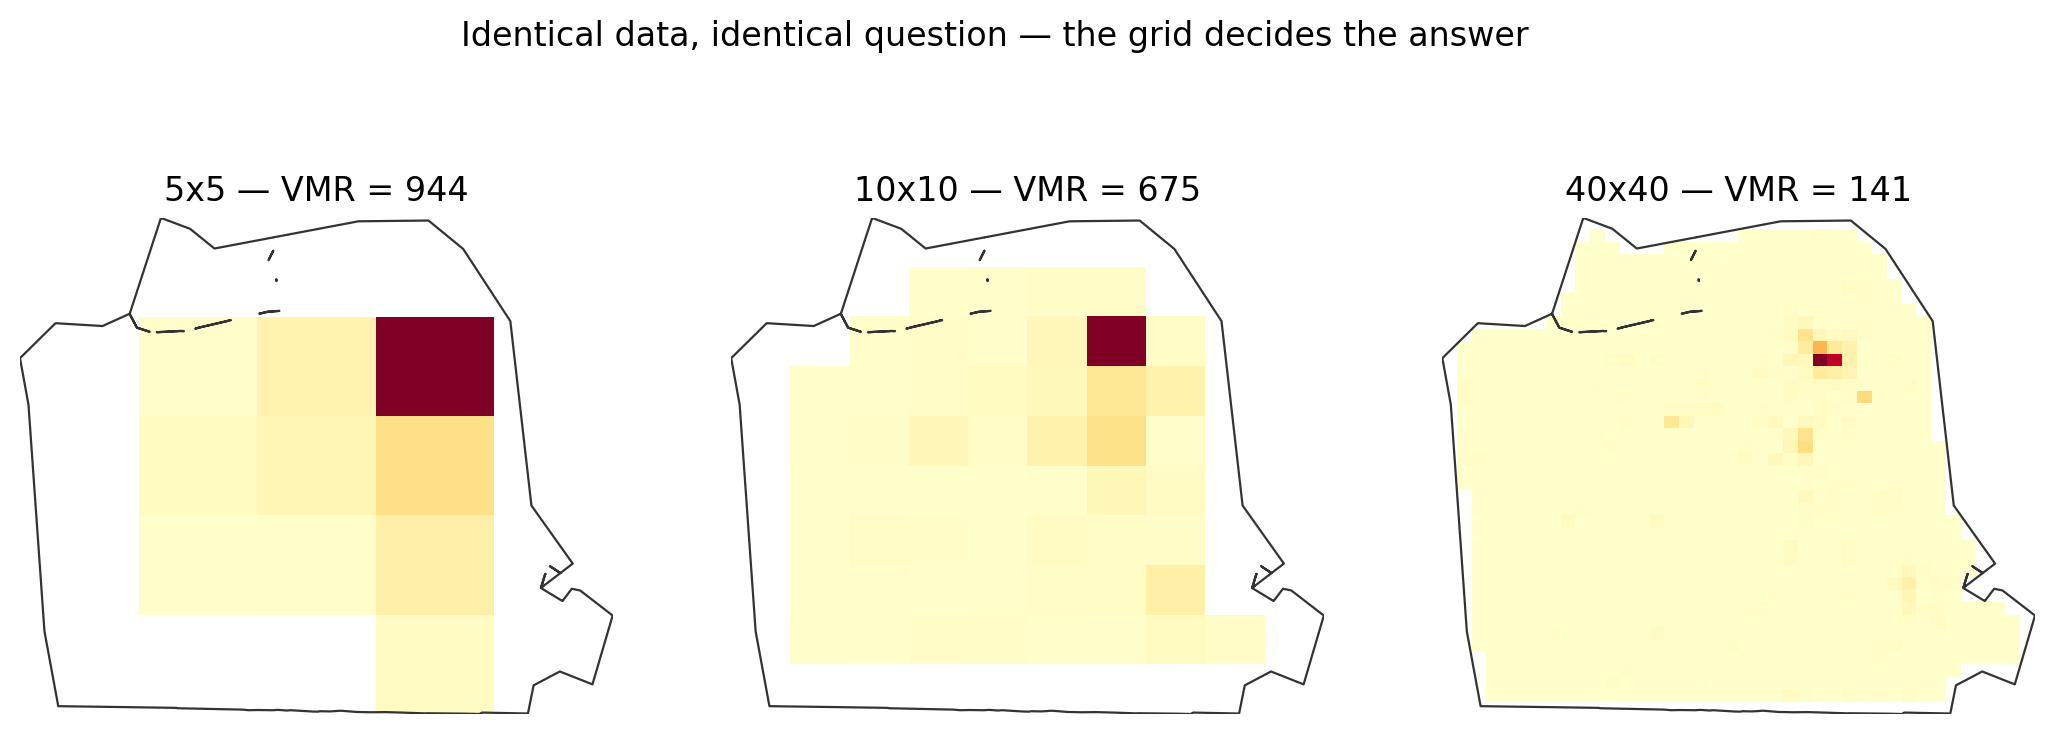

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, m in zip(axes, [5, 10, 40]):
    cnt, keep, (xe, ye) = quadrat_counts(xy(drugs), m)
    shown = np.where(keep, cnt, np.nan)          # NaN = unusable cell, drawn blank
    # .T because histogram2d indexes [x, y] while imshow expects [row, col] = [y, x].
    ax.imshow(shown.T, origin="lower", cmap="YlOrRd",
              extent=[xe[0], xe[-1], ye[0], ye[-1]])
    gpd.GeoSeries([window]).plot(ax=ax, facecolor="none", edgecolor="#333", lw=.8)
    ax.set_title(f"{m}x{m} — VMR = {vmr_test(cnt[keep])[0]:.0f}")
    ax.set_axis_off(); ax.set_aspect("equal")
plt.suptitle("Identical data, identical question — the grid decides the answer")
plt.show()

### Read the output

**VMR swings from ~944 (5×5) to ~141 (40×40).** Nothing about San Francisco changed. Not
one incident moved. Only the grid you drew on it.

The mechanism is visible in the figure and in the table's last column:

- **Big cells (5×5)** average over whole districts. The Tenderloin's spike is diluted into
  a cell that also contains quiet blocks — but the *contrast* between that cell and the
  empty ones is enormous, so VMR is huge.
- **Small cells (40×40)** mostly contain 0 or 1 incidents (798 of 1,157 are empty). Counts
  that small carry almost no information, and the ratio drifts back toward noise.

This is the **Modifiable Areal Unit Problem**, and it is not a bug you can fix — it is a
property of asking a question with boxes. What you can do:

- **Mitigate** — report several resolutions (as above) rather than the one that flatters
  your story; shift the grid origin and check the answer survives.
- **Escape** — use methods with no boxes: **KDE** (§4) smooths instead of binning, and
  **Ripley's $K$** (§5) uses inter-event distances and never bins at all.

> **Lesson —** any statistic computed on an arbitrary grid inherits the arbitrariness: if
> the verdict changes with cell size, the cell size *is* your finding.

---

## 4) KDE: the bandwidth *is* the map

Quadrats chop space into hard boxes, and we just watched the boxes decide the answer. KDE
removes the boxes: drop a smooth **bump** (a kernel) on every event and **add the bumps
up**. Where events crowd, the bumps pile into a peak.

$$\hat\lambda(s)=\frac{1}{h^2}\sum_{i=1}^{n} K\!\left(\frac{\lVert s-s_i\rVert}{h}\right)$$

- $K$ — the **kernel**: a symmetric bump (Gaussian, quartic). Nearer events contribute more.
- $h$ — the **bandwidth**: how wide each bump spreads.

Here is the thing nobody tells you early enough: **the kernel shape barely matters, and
the bandwidth decides everything.** $h$ is a bias–variance dial, and it is the same dial
as the quadrat cell size — MAUP wearing a smoother coat.

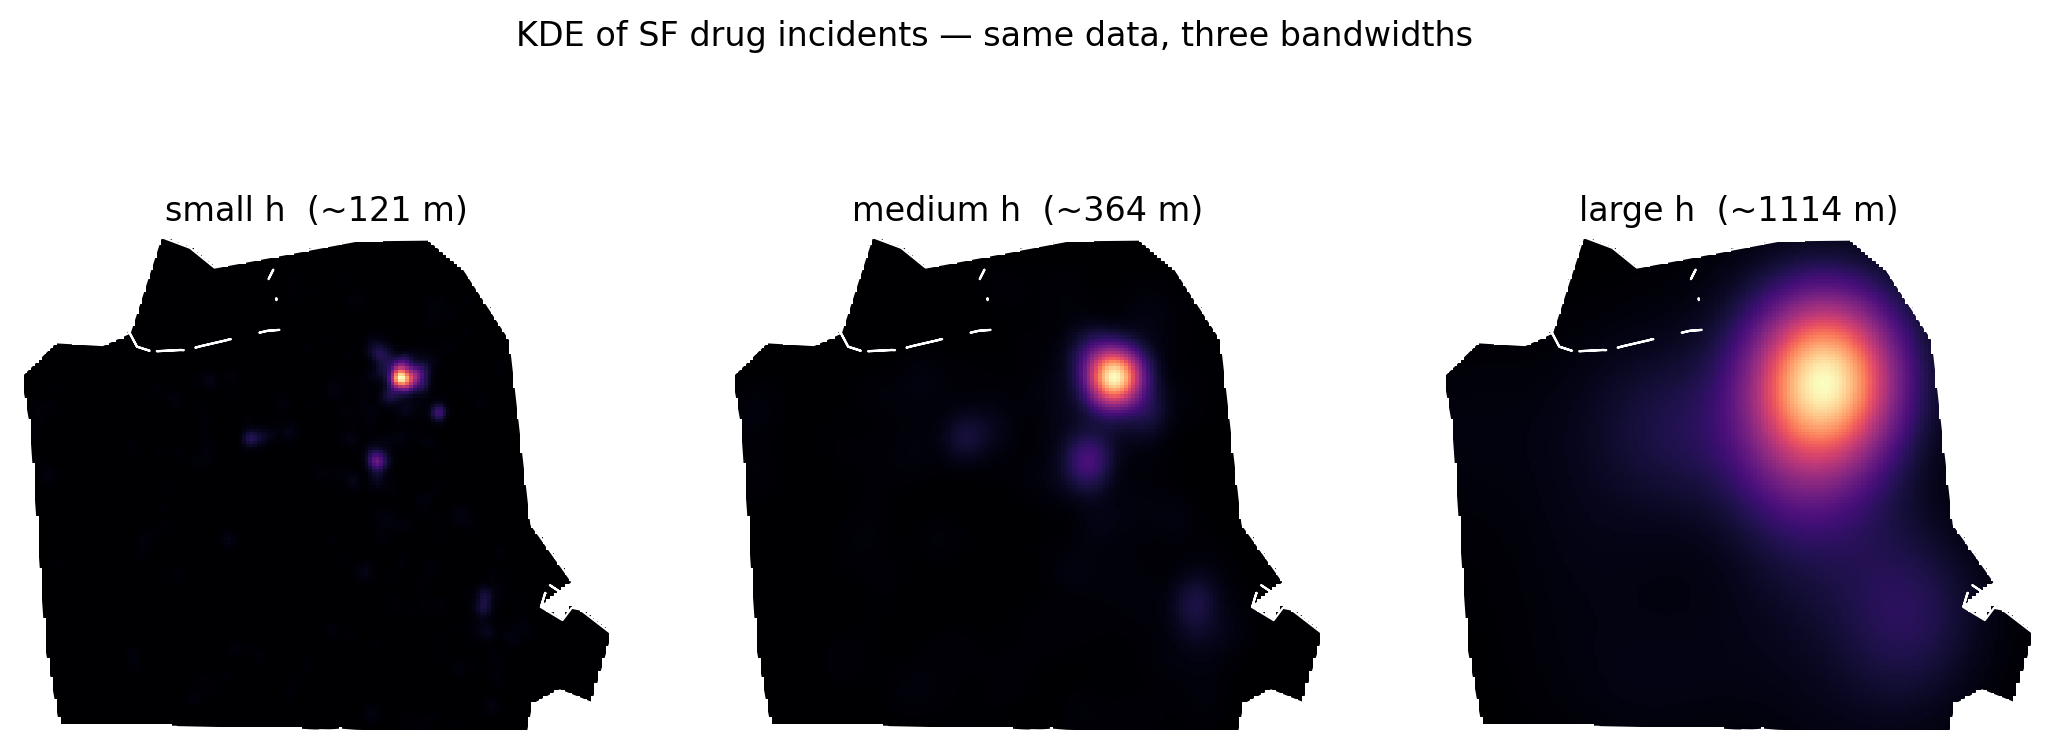

In [12]:
from scipy.stats import gaussian_kde

# Subsample for speed: gaussian_kde evaluates every event against every grid node, and
# 3,896 x 25,600 is needlessly slow for a teaching figure. The surface is stable at 1,500.
sub = xy(drugs)[rng.choice(len(drugs), 1500, replace=False)]

# Build the grid we will evaluate the density on.
gx = np.linspace(minx, maxx, 160)
gy = np.linspace(miny, maxy, 160)
MX, MY = np.meshgrid(gx, gy)

# Mask the ocean: density is only meaningful where crime could occur.
on_land = np.array([pw.contains(Point(a, b))
                    for a, b in zip(MX.ravel(), MY.ravel())]).reshape(MX.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
for ax, bw, lab in [(axes[0], 0.06, "small"), (axes[1], 0.18, "medium"), (axes[2], 0.55, "large")]:
    # scipy's bw_method is a MULTIPLIER on the data's standard deviation, not a distance.
    # We convert it to metres below so the number means something on the ground.
    kde = gaussian_kde(sub.T, bw_method=bw)
    Z = np.where(on_land, kde(np.vstack([MX.ravel(), MY.ravel()])).reshape(MX.shape), np.nan)
    ax.imshow(Z, origin="lower", cmap="magma", extent=[minx, maxx, miny, maxy])
    gpd.GeoSeries([window]).plot(ax=ax, facecolor="none", edgecolor="#fff", lw=.8)
    h_m = bw * np.sqrt(np.cov(sub.T)[0, 0]) / FT_PER_M     # multiplier -> metres
    ax.set_title(f"{lab} h  (~{h_m:.0f} m)")
    ax.set_axis_off(); ax.set_aspect("equal")
plt.suptitle("KDE of SF drug incidents — same data, three bandwidths")
plt.show()

### Read the output

Same data. Three maps. Three different cities:

- **Small $h$ (~116 m)** — you find the Tenderloin, *and* a rash of specks that are single
  incidents. **High variance**: you are mapping noise and calling it a hotspot. Show this
  map to a commander and they will send a patrol to a speck that was one arrest.
- **Medium $h$ (~349 m)** — three credible hotspots: Tenderloin, Mission, Bayview. This
  one is defensible.
- **Large $h$ (~1 km)** — one warm blob over half the city. Perfectly true and perfectly
  useless. **High bias**: real structure blurred into the background.

Choosing $h$ is choosing what you will believe. There are data-driven rules (Silverman's
rule, likelihood cross-validation) and **adaptive** bandwidths that widen where events are
sparse and narrow where they are dense — but there is no escaping that it is a choice you
must defend.

And now the limitation that motivates the rest of the notebook: **KDE cannot tell you
why.** It maps *intensity* — where events are dense — and has no opinion about whether
that density comes from dealing attracting dealing, or simply from that being where the
people are. It will happily paint a beautiful hotspot over a place whose only distinction
is that lots of people live there.

> **Lesson —** choose the bandwidth deliberately: too small invents hotspots, too large
> hides them — the bandwidth, not the kernel, makes or breaks the map.

---

## 5) Second-order: do events *interact*? — and the trap that makes NNI lie

Everything so far was **first-order**: variation in intensity, the map of *where*.
**Second-order** methods ask a different question — do events **influence one another**?
Attraction (contagion), repulsion (competition), or indifference?

We already have the quick check from §1: **NNI**. Run it on the real drug incidents.

In [13]:
d_obs, d_exp, index = nni(xy(drugs), area=area_ft2)
print(f"drug incidents: mean NN distance = {d_obs/FT_PER_M:6.1f} m")
print(f"                expected under CSR = {d_exp/FT_PER_M:6.1f} m")
print(f"                NNI = {index:.3f}   -> 'extreme clustering!'")

drug incidents: mean NN distance =    5.4 m
                expected under CSR =   89.0 m
                NNI = 0.061   -> 'extreme clustering!'


**Stop.** NNI = 0.061 says the average drug incident's nearest neighbour is **5 metres**
away, where randomness predicts 89 m. That would be one of the most concentrated point
patterns ever recorded.

It is an artifact. Any result this extreme should trigger suspicion of *your data* before
excitement about *the world*. **Look at the coordinates themselves** — the step almost
nobody takes:

In [14]:
for name, g in [("drugs", drugs), ("cartheft", cartheft)]:
    pts = xy(g)
    # np.unique over rows: how many DISTINCT coordinates are there, really?
    uniq, counts = np.unique(pts, axis=0, return_counts=True)
    print(f"{name:9s} {len(pts):5,} events at {len(uniq):5,} distinct coordinates "
          f"({len(uniq)/len(pts)*100:4.0f}%)   busiest site: {counts.max()} events")

# How many events have a nearest neighbour at distance EXACTLY zero?
pts = xy(drugs)
d, _ = cKDTree(pts).query(pts, k=2)
print(f"\ndrug incidents whose nearest neighbour is at distance EXACTLY 0: "
      f"{int((d[:, 1] == 0).sum()):,} of {len(pts):,}")

drugs     3,896 events at 1,076 distinct coordinates (  28%)   busiest site: 105 events
cartheft  3,377 events at 2,790 distinct coordinates (  83%)   busiest site: 18 events

drug incidents whose nearest neighbour is at distance EXACTLY 0: 3,705 of 3,896


### Read the output — this is the most useful slide in the section

**3,896 drug incidents occupy 1,076 distinct locations.** One single coordinate carries
**105** incidents. **3,705 of 3,896** events have a nearest neighbour at distance *exactly
zero*.

Why? Crime data is geocoded to **block faces and intersections**, not doorways — partly
for privacy, partly because that is simply what address geocoding returns. The coordinates
are snapped to a street grid.

So $\bar d_{\text{obs}}$ collapses toward zero, and **NNI = 0.061 measures the geocoder's
rounding rule, not San Francisco.** Report it and you have published a data provider's
address-matching policy as a scientific finding.

**The fix:** analyse **distinct sites**. The repeat count doesn't vanish — it becomes a
*mark* on each site (a value attached to a location), which is real information you can
model separately. It is just not a *location*.

In [15]:
# Collapse to distinct geocoded locations; keep the repeat count as a mark.
def sites(g):
    u, c = np.unique(xy(g), axis=0, return_counts=True)
    return u, c

comparison = {}
for name, g in [("drugs", drugs),
                ("robbery", gpd.read_file(GPKG, layer="robbery")),
                ("car theft", cartheft),
                ("vandalism", gpd.read_file(GPKG, layer="vandalism"))]:
    u, c = sites(g)
    comparison[name] = {"events": len(g), "sites": len(u),
                        "unique %": f"{len(u)/len(g)*100:.0f}%",
                        "NNI raw": round(nni(xy(g), area_ft2)[2], 3),
                        "NNI on sites": round(nni(u, area_ft2)[2], 3)}
pd.DataFrame(comparison).T

,events,sites,unique %,NNI raw,NNI on sites
drugs,3896,1076,28%,0.061,0.586
robbery,2759,1562,57%,0.346,0.655
car theft,3377,2790,83%,0.613,0.783
vandalism,3422,2777,81%,0.58,0.734


### Read the output

De-duplicated, drugs read **NNI = 0.586** — still clustered, but **ten times less
dramatic**. The entire difference between "the most extreme pattern I have ever seen" and
"meaningfully clustered" was a data-cleaning decision.

Now look down the `unique %` column, because it tells a story:

| | unique | why |
|---|---|---|
| **drugs** | 28% | recorded at the *address of the arrest* — the same corner, over and over |
| **robbery** | 57% | often an intersection |
| **car theft / vandalism** | 83% / 81% | recorded *where the vehicle stood* — anywhere on any street |

The artifact tracks **reporting practice**, exactly as it should. That coherence is what
tells you the diagnosis is right rather than a coincidence.

> **Lesson —** tied coordinates masquerade as clustering; inspect the resolution of your
> geocoding before any nearest-neighbour statistic, or you will publish the data
> provider's rounding rule as a scientific finding.

---

## 6) $G$, $F$, $K$ — use the whole distribution, at every scale

NNI throws away almost everything: one distance per event, collapsed to one number, at one
scale. If events cluster at 100 m but repel at 10 m, NNI reports a single muddled average.

These three use the **full distribution** of distances, at **every** scale. Each probes
something different, which is exactly why you read them together:

| | what it measures | clustering shows up as |
|---|---|---|
| **$G$** | event → its nearest event | **above** CSR (neighbours are close) |
| **$F$** | *random location* → nearest event | **below** CSR (big voids) |
| **$K$** | events within radius $d$ of a typical event | **above** CSR (excess neighbours) |

**Why does $F$ flip direction?** Because it probes **gaps, not neighbours**. Clustering
packs events together and therefore leaves large empty areas between clusters. Drop a
random test location and it will typically land in a void — *far* from any event — so its
CDF rises **late**, i.e. below CSR. $G$ up and $F$ down are the *same* finding seen from
two sides. Don't memorise the table; remember what each one probes and re-derive it.

**How to judge "above" or "below":** simulate. We generate 99 CSR patterns in the same
window, compute the same curve on each, and shade the 2.5th–97.5th percentile band. If the
observed curve leaves the band, CSR does not plausibly produce it.

$K$ is plotted as the variance-stabilised $L(d) - d$, which is **flat at zero** under CSR
— far easier to read than a curve that grows like $d^2$.

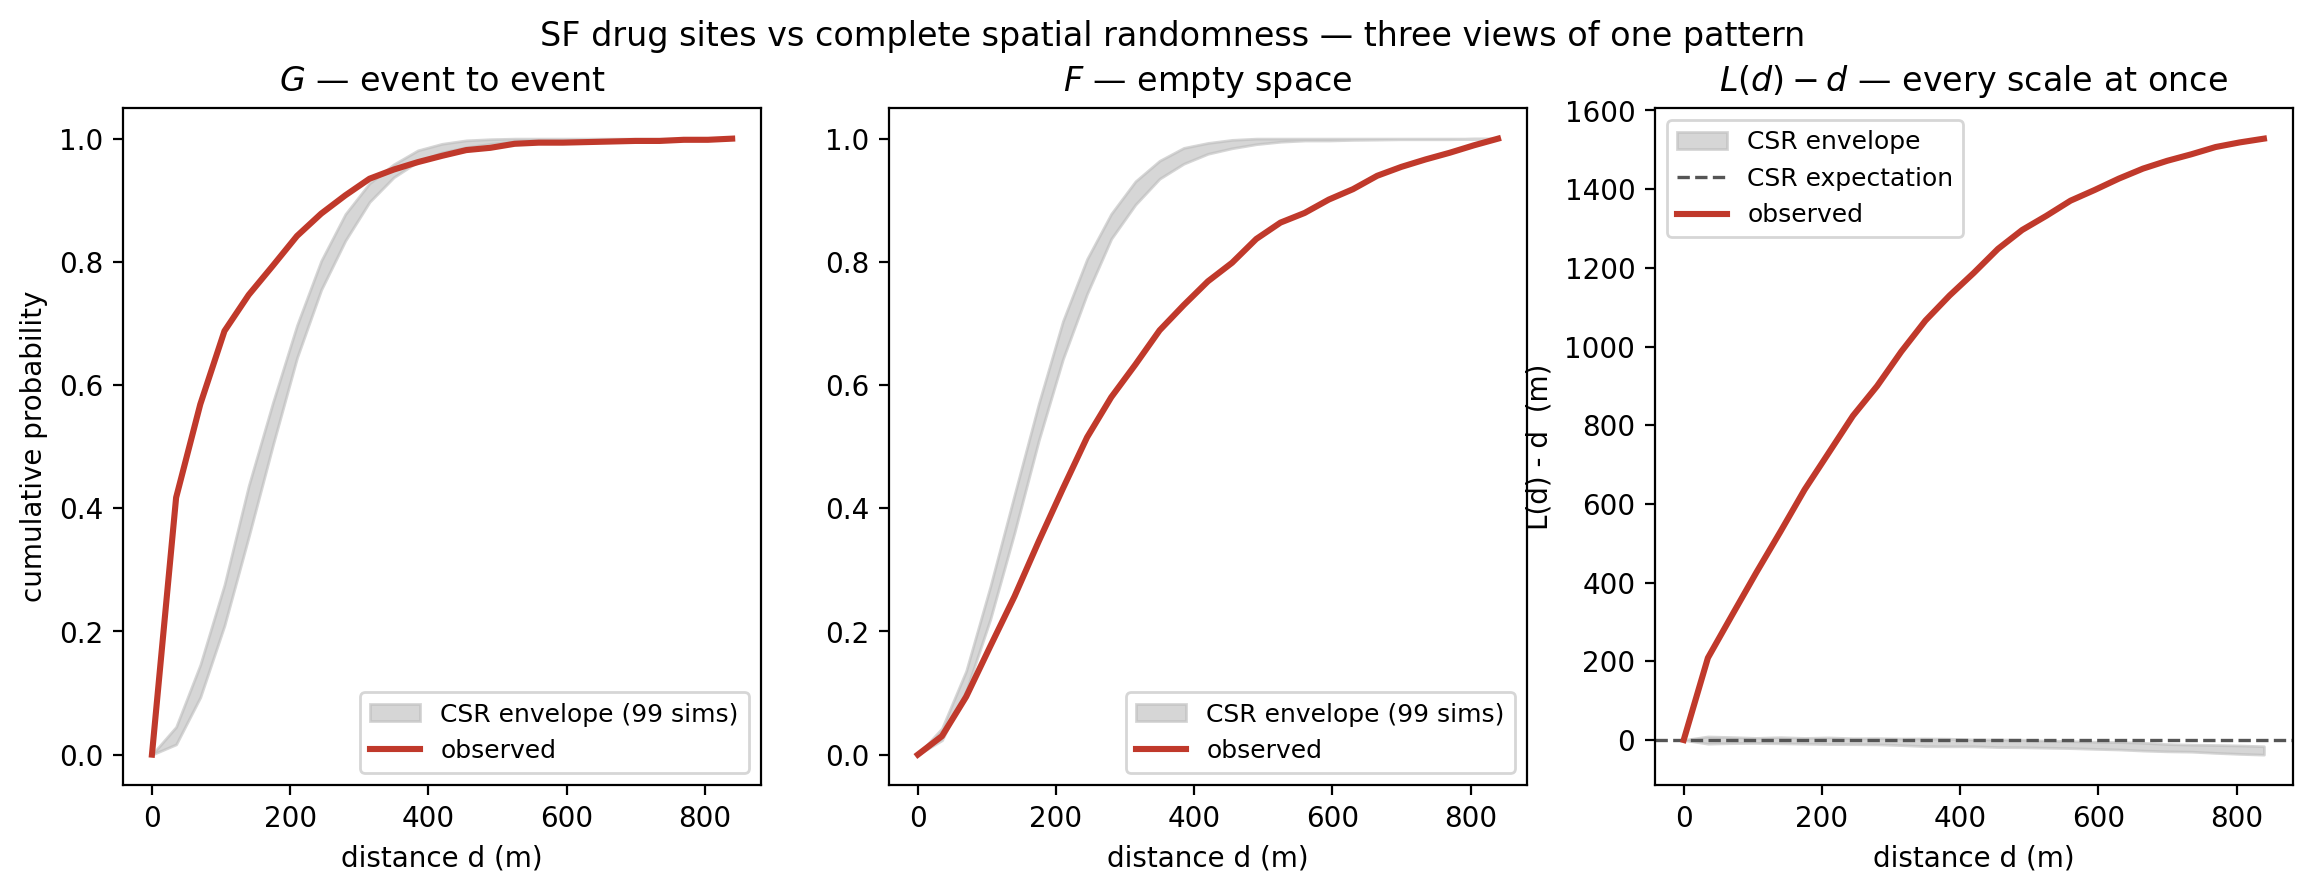

In [16]:
pts_drugs, _ = sites(drugs)      # de-duplicated, per §5 — never run these on tied coords

# Each *_test call computes the observed curve AND n_simulations CSR curves.
# support=25 -> evaluate at 25 distances; keep_simulations=True -> keep the envelope.
# 99 sims is the classroom setting; use 999 for anything you publish.
gt = g_test(pts_drugs, support=25, n_simulations=99, keep_simulations=True)
ft = f_test(pts_drugs, support=25, n_simulations=99, keep_simulations=True)
kt = k_test(pts_drugs, support=25, n_simulations=99, keep_simulations=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

for ax, res, name in [(axes[0], gt, "$G$ — event to event"),
                      (axes[1], ft, "$F$ — empty space")]:
    sup = res.support / FT_PER_M                        # distances -> metres
    lo, hi = np.percentile(res.simulations, [2.5, 97.5], axis=0)
    ax.fill_between(sup, lo, hi, color="#bbb", alpha=.6, label="CSR envelope (99 sims)")
    ax.plot(sup, res.statistic, color="#c0392b", lw=2.2, label="observed")
    ax.set_title(name); ax.set_xlabel("distance d (m)"); ax.legend(fontsize=9)
axes[0].set_ylabel("cumulative probability")

# K -> L(d) - d. L(d) = sqrt(K(d)/pi) linearises K; subtracting d puts CSR at exactly 0.
ax = axes[2]
sup = kt.support / FT_PER_M
L = lambda K: np.sqrt(np.maximum(K, 0) / np.pi) / FT_PER_M
lo, hi = np.percentile(np.array([L(s) - sup for s in kt.simulations]), [2.5, 97.5], axis=0)
ax.fill_between(sup, lo, hi, color="#bbb", alpha=.6, label="CSR envelope")
ax.axhline(0, color="#555", ls="--", lw=1.2, label="CSR expectation")
ax.plot(sup, L(kt.statistic) - sup, color="#c0392b", lw=2.2, label="observed")
ax.set_title("$L(d)-d$ — every scale at once"); ax.set_xlabel("distance d (m)")
ax.set_ylabel("L(d) - d  (m)"); ax.legend(fontsize=9)

plt.suptitle("SF drug sites vs complete spatial randomness — three views of one pattern")
plt.show()

### Read the output

- **$G$ is above the envelope** — about 70% of drug sites have another within ~120 m; CSR
  says ~30%. Neighbours are far closer than chance.
- **$F$ is below the envelope** — random test locations sit *far* from any drug site. The
  voids are real, and they are large.
- **$L(d)-d$ is far above 0 at every distance** — this is not a bump at one scale; the
  concentration persists all the way out.

**All three agree.** That matters more than any one of them: three probes with different
blind spots telling one story is what makes the finding credible. Disagreement (say, $G$
above but $K$ inside its envelope) would point to structure at one scale only, and would
be interesting in its own right.

Notice the envelopes are *narrow*. With ~1,000 sites, CSR is tightly constrained — which
is why the observed curves are not just outside the band but nowhere near it.

Now put a **number** on it. $K(d)\lambda$ is the expected count of neighbours within $d$ of
a typical event; under CSR that is $\pi d^2 \lambda$. Their **ratio** is an effect size you
can quote to a non-specialist.

In [17]:
# Observed vs CSR-expected neighbours within a radius — the effect size.
def excess(pts, radius_m=500, n_sims=99):
    kt = k_test(pts, support=20, n_simulations=n_sims, keep_simulations=True)
    i = np.argmin(np.abs(kt.support - radius_m * FT_PER_M))  # nearest evaluated distance
    lam = len(pts) / area_ft2
    obs = kt.statistic[i] * lam            # K(d) * lambda = mean neighbours within d
    exp = np.pi * kt.support[i] ** 2 * lam # CSR expectation: lambda * area of the circle
    return kt.support[i] / FT_PER_M, obs, exp, obs / exp

effect = {}
for name, g in [("drug sites", drugs), ("car theft sites", cartheft)]:
    pts, _ = sites(g)
    r, obs, exp, ratio = excess(pts)
    effect[name] = ratio
    print(f"{name:16s} within {r:.0f} m: {obs:5.1f} neighbours observed vs "
          f"{exp:4.1f} expected under CSR  ->  x{ratio:.2f}")

ratio_drugs, ratio_ct = effect["drug sites"], effect["car theft sites"]

drug sites       within 486 m:  86.6 neighbours observed vs  6.5 expected under CSR  ->  x13.38


car theft sites  within 510 m:  36.2 neighbours observed vs 18.5 expected under CSR  ->  x1.96


### Read the output

- **Drug sites: ×13.4** — thirteen times the neighbours randomness predicts.
- **Car theft sites: ×2.0** — twice.

Both are "significant at $p<0.001$". They are not remotely the same finding. Drug dealing
concentrates on *specific corners that work*: sightlines, foot traffic, escape routes. Cars
get stolen roughly wherever cars are parked.

> **Lesson —** a $p$-value says a departure exists; only an effect size says whether it
> matters.

And now the question this whole notebook has been walking toward:

> **Is car theft's ×2.0 evidence that thefts *interact* — or just that cars and people are
> unevenly spread across the city?**

Ripley's $K$ cannot tell you. Neither can $G$, $F$, NNI, KDE, or the quadrat test. Every
statistic so far compares against **homogeneous** CSR, which assumes constant intensity —
so *any* violation of constant intensity gets reported as "clustering".

---

## 7) The trap: interaction, or just people?

Here is the experiment that settles it — and it is the reason the notebook exists.

We scatter points with **zero interaction by construction**. No point influences any other;
we draw each one independently. But we make the intensity **proportional to block
population**: more points where more people live. That violates CSR's *first* assumption
(uniform intensity) while the *second* (independence) holds **exactly, by construction**.

We know the truth, because we made it. There is no interaction. None.

**So if our statistics shout "clustered!" at this pattern, then shouting "clustered!" at
the real data proves nothing about interaction.**

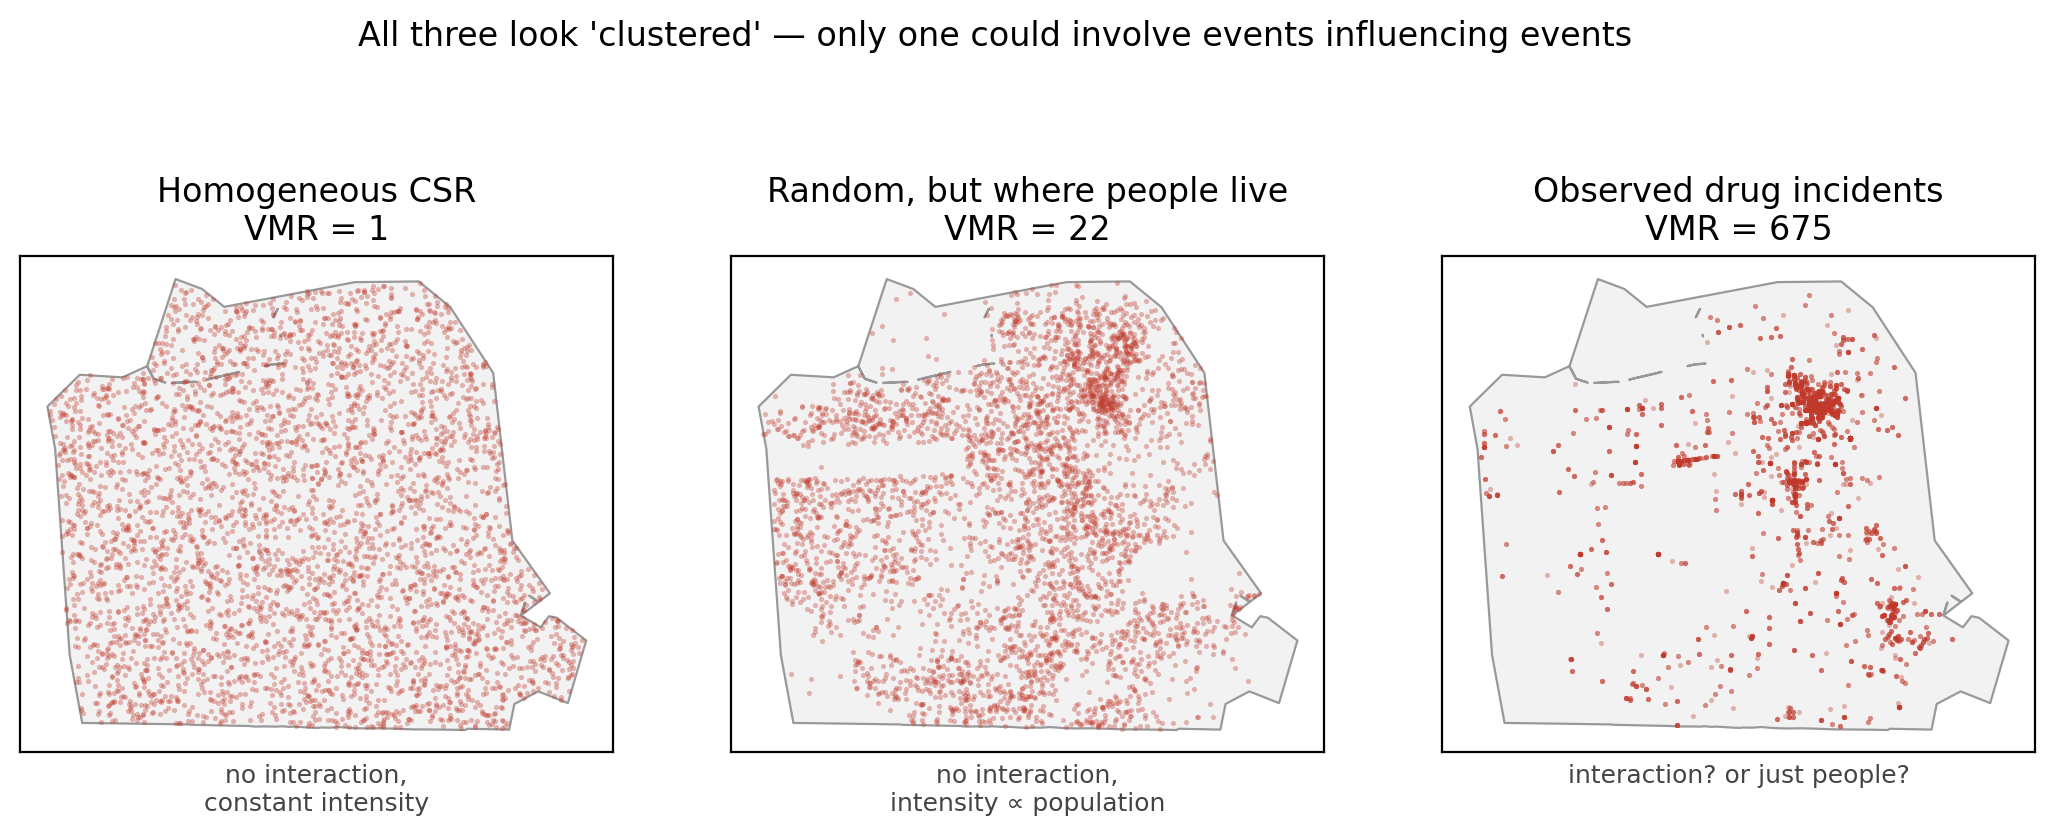

In [18]:
# Draw n events independently, with probability proportional to each block's population.
# Independence holds exactly: no point's location depends on any other point's location.
# Only the INTENSITY varies across space.
def population_sample(n, rng):
    pop = np.nan_to_num(blocks.Population.to_numpy(dtype=float))
    # Choose which block each event lands in, weighted by population...
    draw = rng.choice(len(blocks), size=n, p=pop / pop.sum())
    pts = []
    # ...then place it uniformly at random *within* that block.
    for bi, k in pd.Series(draw).value_counts().items():
        poly = blocks.geometry.iloc[bi]
        pp = prep(poly)
        bx0, by0, bx1, by1 = poly.bounds
        got = 0
        while got < k:
            px = rng.uniform(bx0, bx1, 60); py = rng.uniform(by0, by1, 60)
            for a, b in zip(px, py):
                if got >= k:
                    break
                if pp.contains(Point(a, b)):
                    pts.append((a, b)); got += 1
    return np.array(pts)

pts_pop = population_sample(len(drugs), rng)   # no interaction, intensity ∝ population
pts_csr = csr_sample(len(drugs), rng)          # no interaction, constant intensity
_, _, nni_csr = nni(pts_csr, area_ft2)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, pts, title, sub in [
    (axes[0], pts_csr, "Homogeneous CSR", "no interaction,\nconstant intensity"),
    (axes[1], pts_pop, "Random, but where people live", "no interaction,\nintensity ∝ population"),
    (axes[2], xy(drugs), "Observed drug incidents", "interaction? or just people?")]:
    cnt, keep, _ = quadrat_counts(pts)
    gpd.GeoSeries([window]).plot(ax=ax, color="#f2f2f2", edgecolor="#999", lw=.8)
    ax.scatter(pts[:, 0], pts[:, 1], s=3.5, c="#c0392b", alpha=.35, lw=0)
    ax.set_title(f"{title}\nVMR = {vmr_test(cnt[keep])[0]:.0f}")
    ax.set_xlabel(sub, fontsize=9, color="#444")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
plt.suptitle("All three look 'clustered' — only one could involve events influencing events")
plt.show()

Look at the middle panel before reading on. It has **structure**. It has a dense knot
downtown and sparse edges. Shown it cold, you would call it clustered — and you would be
right, in the sense that VMR ≈ 25 versus 1 for homogeneous CSR. **And there is no
interaction in it at all.** The knot is just Chinatown and the northeast having residents.

Now run the *same statistics we ran on the real data* against it. One draw is one draw, so
replicate ten times and report the spread.

In [19]:
# One draw proves nothing; replicate and report the range.
# n_sims=9 inside excess() keeps this fast — we need its point estimate, not its envelope.
ratios, nnis = [], []
for rep in range(10):
    p = population_sample(len(drugs), rng)
    p = p[rng.choice(len(p), len(pts_drugs), replace=False)]   # match the drug SITE count
    ratios.append(excess(p, n_sims=9)[3])
    nnis.append(nni(p, area_ft2)[2])
ratios, nnis = np.array(ratios), np.array(nnis)

print("Population-proportional points — ZERO interaction by construction, 10 replicates:")
print(f"  NNI            : {nnis.mean():.3f}  (range {nnis.min():.3f}–{nnis.max():.3f});"
      f"  homogeneous CSR gives {nni_csr:.3f}")
print(f"  K excess @~500m: x{ratios.mean():.2f}  (range x{ratios.min():.2f}–x{ratios.max():.2f})")
print()
print(f"  Observed car theft: x{ratio_ct:.2f}   <- inside the range above")
print(f"  Observed drugs    : x{ratio_drugs:.2f}   <- far beyond it")

Population-proportional points — ZERO interaction by construction, 10 replicates:
  NNI            : 0.870  (range 0.844–0.903);  homogeneous CSR gives 0.989
  K excess @~500m: x1.88  (range x1.74–x2.01)

  Observed car theft: x1.96   <- inside the range above
  Observed drugs    : x13.38   <- far beyond it


### Read the output — the punchline

Ripley's $K$ reports **×1.8 (range 1.6–2.0)** for a pattern in which **nothing interacted
with anything**. NNI reports ~0.87, comfortably "clustered".

**Car theft's observed ×2.0 sits inside that range.**

Read that again. Car theft's entire second-order "clustering" signal is **fully consistent
with nothing but where people (and their cars) are**. On this evidence you cannot claim
thefts influence each other — not because the test was weak, but because the test was
answering a different question than you thought.

Drugs' **×13.4** is far outside anything population inhomogeneity reproduced. *That*
survives the objection, and is where a genuine interaction story could begin.

**CSR failed for the middle panel because intensity varies — not because events interact.**
Our tests cannot distinguish those. Only a **better null** can.

*(Honest caveat: this is a heuristic, not a formal test. Block population is a rough proxy
for cars-at-risk — parking density, not residents, drives car theft exposure. The formal
tools are below. The point stands regardless: a plausible inhomogeneity reproduces car
theft's effect size without a shred of interaction.)*

### This is Part 1's "three suspects", in point-pattern clothing

The deck opened with a crime hotspot and three suspects behind it. Point patterns re-run
the same drama with different names:

| Suspect (Part 1) | Point-pattern name | The fix |
|---|---|---|
| **Shared cause** *(confounding)* | inhomogeneous intensity $\lambda(s)$ | put the driver **in the null** |
| **Contagion** *(diffusion)* | genuine **interaction** | whatever survives that null |

**The tools that do it properly:**

- **Inhomogeneous Poisson null** — simulate with $\lambda(s)$ estimated from a covariate
  (population, land use, road density) instead of a constant. Clustering that survives
  *that* envelope is evidence of interaction. This is the formal version of what we just
  did by hand.
- **$K_{\text{inhom}}$** — Ripley's $K$ with the varying intensity divided out
  (`spatstat::Kinhom` in R).
- **Case–control** — compare cases against a *control* point pattern carrying the same
  population-at-risk. Disease mapping's standard move, for exactly this reason: to show a
  cancer cluster you compare against where *people* are, never against a uniform map.

The statistics were the easy part. **The null model is where you encode which question you
are actually asking** — and it is the part that requires you to know something about the
world, not just about Python.

> **Lesson —** rejecting CSR proves only that the homogeneous-Poisson story is wrong;
> attributing that to interaction, when the cause is uneven intensity, is the most common
> error in point pattern analysis.

---

## 8) Takeaways

1. **The locations are the data**, and the window is part of the data: $\lambda = n/|A|$,
   so redrawing the boundary silently rewrites every result.
2. **Everything is measured against a null.** CSR = constant intensity **and**
   independence — two assumptions bundled into one rejection.
3. **First-order** (quadrats, KDE) maps *where*; **second-order** ($G$, $F$, $K$) asks
   whether events *interact*.
4. **Every first-order tool has a scale knob** — quadrat size, bandwidth — and the knob
   changes the answer (MAUP): VMR 944 → 141 on identical data.
5. **Look at your coordinates first.** NNI 0.061 → 0.586 once tied geocodes are collapsed.
   The trap tracked reporting practice: drugs 28% unique vs car theft 83%.
6. **Report effect size**, not just $p$: ×13.4 (drugs) vs ×2.0 (car theft), both
   $p<0.001$.
7. **Rejecting CSR is ambiguous.** Population inhomogeneity alone produced ×1.8 (1.6–2.0)
   with zero interaction — bracketing car theft's ×2.0.

> **Lesson —** point pattern analysis is null-model design: the statistics are easy, and
> deciding what "random" should have meant is the entire scientific contribution.

### Your turn — exercises

1. **Swap the crime type.** Re-run §3–§6 with `robbery` or `vandalism` (both are layers in
   the gpkg). Where does each land between drugs' ×13.4 and car theft's ×2.0? Does the
   `unique %` from §5 predict the trouble you have?
2. **Break the window.** Re-compute NNI for drug sites using the *bounding box* area
   instead of the land area (`window.envelope.area`). You should see 0.586 drift to about
   0.517 — SF's bbox is only 1.29× its land, so the lie is small here. Now imagine a
   coastal study area that is 60% water, and ask how much of the literature's "clustering"
   is a boundary someone drew carelessly.
3. **Find the scale.** In §6, the $L(d)-d$ curve peaks somewhere. At what distance? What
   would that distance mean on the ground — a block? a district?
4. **Improve the null.** Our population-proportional null used residents. Car theft
   exposure is really about *parked cars*. Build a null proportional to something better
   (road length per block, or `RetailPSqMi` from `data/incidents/InputDataset.csv`) and
   see whether car theft's ×2.0 still sits inside the range.
5. **Marks.** §5 set aside the repeat counts as marks. Map them: are the busiest sites
   inside the KDE hotspots, or somewhere else entirely? What would each answer imply?

### Where next

- **Marked patterns** — model the repeat counts, don't just discard them.
- **Space–time** — `pointpats` has the Knox and Jacquez tests. Contagion leaves a
  *space–time* signature (near in space **and** near in time) that no static map can show.
  It is the cleanest way to separate suspect 2 from suspect 1.
- **`spatstat` (R)** — `Kinhom`, `envelope`, and model fitting (`ppm`) remain the most
  complete implementation of everything above.